# convexity_defects

My attempts to detect vcuts as convexity defects.

## References
[Medium  article: Contours and Convex Hull in OpenCV Python](https://medium.com/analytics-vidhya/contours-and-convex-hull-in-opencv-python-d7503f6651bc)

In [6]:
import cv2
import numpy as np
from typing import List, Tuple
import matplotlib.pyplot as plt

In [7]:

def detect_v_cuts(image_path: str, visual: bool = True) -> np.ndarray:
    """
    Detects V-shaped notches in palm fronds using convexity defects.
    
    Args:
        image_path: Path to the input image.
        visual: Whether to render a diagnostic image.
        
    Returns:
        A numpy array (binary mask) highlighting detected defect areas.
    """
    # Load image and convert to grayscale
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Thresholding to get the leaf mask (Binary)
    # Using Otsu's to handle varied lighting in field photos
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mask = np.zeros_like(gray)
    
    for cnt in contours:
        # Filter small noise
        if cv2.contourArea(cnt) < 500:
            continue
            
        # 1. Get the Convex Hull
        hull_indices = cv2.convexHull(cnt, returnPoints=False)
        
        # 2. Find Convexity Defects
        # Defects are the gaps between the hull and the actual contour
        if len(hull_indices) > 3:
            defects = cv2.convexityDefects(cnt, hull_indices)
            
            if defects is not None:
                for i in range(defects.shape[0]):
                    s, e, f, d = defects[i, 0]
                    start = tuple(cnt[s][0])
                    end = tuple(cnt[e][0])
                    far = tuple(cnt[f][0])
                    
                    # 'd' is the distance from the farthest point to the hull
                    # V-cuts are typically deep (large d)
                    if d > 1000:  # Threshold based on image resolution
                        # Draw the defect area on our mask
                        cv2.line(mask, start, end, 255, 2)
                        cv2.circle(mask, far, 5, 255, -1)
                        
                        if visual:
                            cv2.line(img, start, end, (0, 255, 0), 2)
                            cv2.circle(img, far, 8, (0, 0, 255), -1)

    return mask if not visual else img

# Example usage:
# result = detect_v_cuts('palm_leaf.jpg')


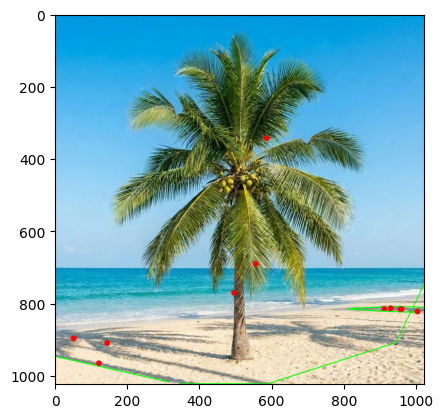

In [18]:
imgpath = 'example_images/sim2.jpg'
img = detect_v_cuts(imagepath, visual=True)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.savefig(f'{imgpath}-processed.png')